# LT3800 Synchronous Buck Converter: Design Analysis
**12V to 3.3V / 2A @ 200kHz**

Author: Guillaume Thenaisie  
Date: 2026-03-15  
Rev: 1.0

---

This notebook documents the analytical verification of the LT3800 buck converter design.  
It covers:
1. Design parameters and component selection rationale
2. Analytical loss breakdown and efficiency curve
3. Small-signal loop gain (Bode plot) from transfer function
4. Key design verdicts

> **Note:** Efficiency was computed analytically rather than from simulation.  
> The LT3800 behavioral SPICE model uses internal artificial current sources  
> that invalidate power measurements in `.tran` analysis.  
> Loop stability was derived from the small-signal averaged model  
> cycle-by-cycle SPICE models are incompatible with `.ac` analysis.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec

# Plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        11,
    'lines.linewidth':  2,
})

## 1. Design Parameters

In [ ]:
# ── Electrical spec ──────────────────────────────────────────────
Vin   = 12.0      # V  — input voltage
Vout  = 3.3       # V  — output voltage
Iout_max = 2.0    # A  — maximum load current
Fsw   = 200e3     # Hz — switching frequency (LT3800 fixed)
Vref  = 1.2       # V  — LT3800 internal reference

# ── Derived ──────────────────────────────────────────────────────
D     = Vout / Vin          # duty cycle
Tsw   = 1 / Fsw             # switching period

# ── Real components (Digikey BOM) ────────────────────────────────
L     = 22e-6     # H   — Bourns SRR1260-220M
DCR   = 43e-3     # Ω   — inductor DC resistance
Cout  = 100e-6    # F   — Murata GRM32ER61A107ME20 (nominal)
Cout_eff = 72e-6  # F   — effective after X5R DC bias derating @ 3.3V
ESR   = 5e-3      # Ω   — output cap ESR
Cin   = 22e-6     # F   — Murata GRM31CR61C226ME15
ESR_in = 8e-3     # Ω   — input cap ESR
Rsense = 20e-3    # Ω   — current sense resistor
Rds_on = 6e-3     # Ω   — CSD17556Q5B Rds(on) typ
tr_tf  = 5e-9     # s   — CSD17556Q5B rise+fall time
Iq     = 100e-6   # A   — LT3800 quiescent current

# ── Feedback divider ─────────────────────────────────────────────
Rbot  = 100e3     # Ω
Rtop  = 175e3     # Ω
H_fb  = Rbot / (Rtop + Rbot)   # feedback attenuation

# ── Type II compensation ─────────────────────────────────────────
Rc    = 10e3     # Ω
Cc    = 10e-9      # F
Cp    = 100e-12    # F

print(f"Duty cycle D          = {D:.3f}")
print(f"Feedback attenuation  = {H_fb:.4f}")
print(f"Cout effective        = {Cout_eff*1e6:.1f} µF  (derated from {Cout*1e6:.0f} µF nominal)")
print(f"Inductor current ripple ΔIL = {(Vin-Vout)*D/(Fsw*L)*1e3:.1f} mA pk-pk")

Duty cycle D          = 0.275
Feedback attenuation  = 0.3636
Cout effective        = 72.0 µF  (derated from 100 µF nominal)
Inductor current ripple ΔIL = 543.8 mA pk-pk


## 2. Loss Breakdown & Efficiency Curve

Loss contributors modelled:
- Q1 (high-side) conduction: $I_{out}^2 \cdot R_{ds} \cdot D$
- Q2 (low-side) conduction: $I_{out}^2 \cdot R_{ds} \cdot (1-D)$
- Inductor DCR: $I_{out}^2 \cdot DCR$
- Sense resistor: $I_{out}^2 \cdot R_{sense}$
- Switching: $\frac{1}{2} V_{in} I_{out} (t_r+t_f) f_{sw}$
- Quiescent: $I_q \cdot V_{in}$

In [ ]:
Iout_range = np.linspace(0.05, Iout_max, 200)

def losses(Iout):
    Iout = np.atleast_1d(np.asarray(Iout, dtype=float))
    P_Q1   = Iout**2 * Rds_on * D
    P_Q2   = Iout**2 * Rds_on * (1 - D)
    P_DCR  = Iout**2 * DCR
    P_Rsns = Iout**2 * Rsense
    P_sw   = 0.5 * Vin * Iout * tr_tf * Fsw
    P_iq   = np.full_like(Iout, Iq * Vin)  # ← broadcast to same shape
    return P_Q1, P_Q2, P_DCR, P_Rsns, P_sw, P_iq

P_Q1, P_Q2, P_DCR, P_Rsns, P_sw, P_iq = losses(Iout_range)
P_total_loss = P_Q1 + P_Q2 + P_DCR + P_Rsns + P_sw + P_iq
Pout_range   = Vout * Iout_range
Pin_range    = Pout_range + P_total_loss
eta          = Pout_range / Pin_range * 100

# ── Operating points matching LTspice .step ───────────────────────
Iout_pts  = np.array([0.1, 0.5, 1.0, 1.5, 2.0])
Pout_pts  = Vout * Iout_pts
loss_pts  = sum(losses(Iout_pts))
eta_pts   = Pout_pts / (Pout_pts + loss_pts) * 100

loss_matrix = np.array(losses(Iout_pts))  # shape (6, 5)
pl_pts = loss_matrix.sum(axis=0)          # sum all loss contributors per load point

print("Load point efficiency:")
print(f"{'Iout (A)':>10} {'Pout (W)':>10} {'Ploss (mW)':>12} {'η (%)':>8}")
print("-" * 44)
for i, io in enumerate(Iout_pts):
    print(f"{io:>10.1f} {Vout*io:>10.2f} {pl_pts[i]*1e3:>12.1f} {eta_pts[i]:>8.1f}")

Load point efficiency:
  Iout (A)   Pout (W)   Ploss (mW)    η (%)
--------------------------------------------
       0.1       0.33          2.5     99.3
       0.5       1.65         21.4     98.7
       1.0       3.30         76.2     97.7
       1.5       4.95        165.5     96.8
       2.0       6.60        289.2     95.8


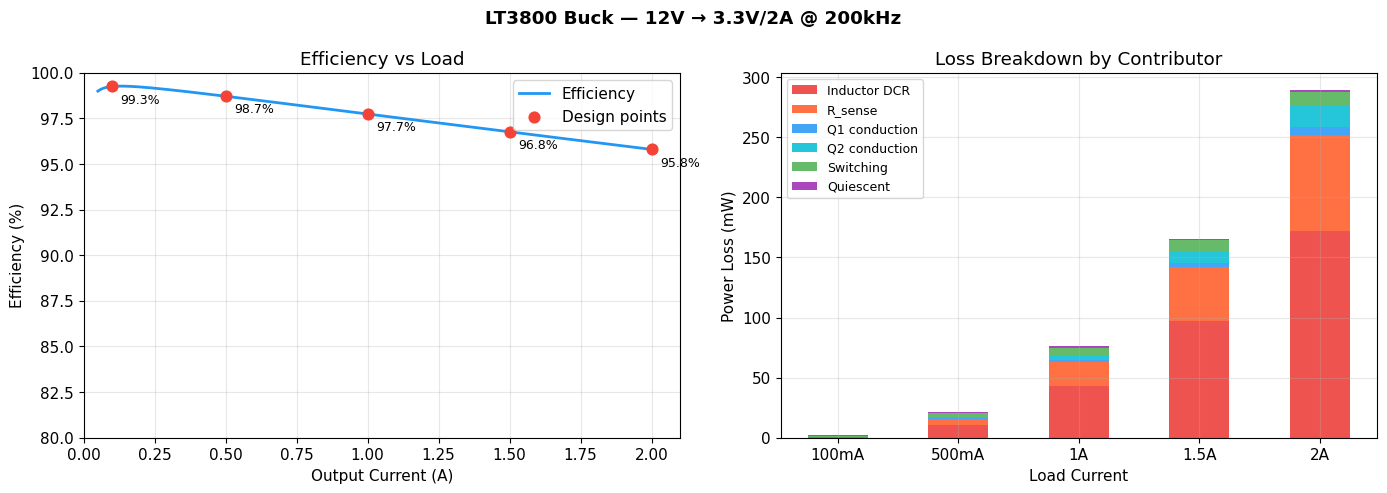

Saved: efficiency_curve.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LT3800 Buck — 12V → 3.3V/2A @ 200kHz', fontweight='bold')

# ── Efficiency curve ──────────────────────────────────────────────
ax1 = axes[0]
ax1.plot(Iout_range, eta, color='#2196F3', label='Efficiency')
ax1.scatter(Iout_pts, eta_pts, color='#F44336', zorder=5,
            label='Design points', s=60)
for io, eff in zip(Iout_pts, eta_pts):
    ax1.annotate(f'{eff:.1f}%', (io, eff),
                 textcoords='offset points', xytext=(6, -12), fontsize=9)
ax1.set_xlabel('Output Current (A)')
ax1.set_ylabel('Efficiency (%)')
ax1.set_title('Efficiency vs Load')
ax1.set_xlim(0, 2.1)
ax1.set_ylim(80, 100)
ax1.legend()

# ── Loss breakdown stacked bar ────────────────────────────────────
ax2 = axes[1]
labels = ['100mA', '500mA', '1A', '1.5A', '2A']
P_Q1_pts, P_Q2_pts, P_DCR_pts, P_Rsns_pts, P_sw_pts, P_iq_pts = [
    l * 1e3 for l in losses(Iout_pts)]

x = np.arange(len(labels))
w = 0.5
b1 = ax2.bar(x, P_DCR_pts,  w, label='Inductor DCR',   color='#EF5350')
b2 = ax2.bar(x, P_Rsns_pts, w, bottom=P_DCR_pts,
             label='R_sense',        color='#FF7043')
b3 = ax2.bar(x, P_Q1_pts,   w, bottom=P_DCR_pts+P_Rsns_pts,
             label='Q1 conduction',  color='#42A5F5')
b4 = ax2.bar(x, P_Q2_pts,   w, bottom=P_DCR_pts+P_Rsns_pts+P_Q1_pts,
             label='Q2 conduction',  color='#26C6DA')
b5 = ax2.bar(x, P_sw_pts,   w,
             bottom=P_DCR_pts+P_Rsns_pts+P_Q1_pts+P_Q2_pts,
             label='Switching',      color='#66BB6A')
b6 = ax2.bar(x, P_iq_pts,   w,
             bottom=P_DCR_pts+P_Rsns_pts+P_Q1_pts+P_Q2_pts+P_sw_pts,
             label='Quiescent',      color='#AB47BC')

ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_xlabel('Load Current')
ax2.set_ylabel('Power Loss (mW)')
ax2.set_title('Loss Breakdown by Contributor')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('efficiency_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: efficiency_curve.png")

## 3. Small-Signal Loop Gain: Bode Plot

Current mode buck loop gain:

$$T(s) = G_{vd}(s) \cdot G_c(s) \cdot H_{fb}$$

**Plant** (LC filter with load):
$$G_{vd}(s) = \frac{V_{in}}{1 + s\frac{L}{R_{load}} + s^2 L C_{out}}$$

**Type II Compensator:**
$$G_c(s) = \frac{1}{sR_c} \cdot \frac{1 + sR_cC_c}{1 + s\frac{C_cC_p}{C_c+C_p}R_c}$$

In [ ]:
# Debug — print gain at key frequencies
freqs_debug = [10, 100, 1000, 5000, 10000, 50000, 100000]
print(f"{'Freq (Hz)':>12} {'|T| (dB)':>12} {'Phase (°)':>12}")
print("-" * 38)
for fd in freqs_debug:
    idx = np.argmin(np.abs(f - fd))
    print(f"{fd:>12} {T_dB[idx]:>12.1f} {T_ph[idx]:>12.1f}")

print(f"\nT_dB max = {T_dB.max():.1f} dB")
print(f"T_dB min = {T_dB.min():.1f} dB")
print(f"Km = {Km:.3f}")

   Freq (Hz)     |T| (dB)    Phase (°)
--------------------------------------
          10         92.1        -90.1
         100         72.1        -90.8
        1000         51.6        -96.2
        5000         36.6       -100.7
       10000         30.3       -107.1
       50000         11.9       -144.9
      100000          1.0       -160.7

T_dB max = 92.1 dB
T_dB min = -78.4 dB
Km = 22.008


In [ ]:
f   = np.logspace(1, 7, 2000)
w   = 2 * np.pi * f
s   = 1j * w

Rload = Vout / Iout_max           # 1.65Ω

# LT3800 error amplifier transconductance (datasheet typ)
gm_ea = 200e-6                    # A/V

# Current mode plant — single pole
G_vd = Rload / (1 + s * Rload * Cout_eff)

# Modulator gain
dIL    = (Vin - Vout) * D / (Fsw * L)
IL_peak = Iout_max + dIL / 2
Km     = 1 / (Rsense * IL_peak)

# Type II compensator — correct topology for gm error amp
# Z_comp = (Rc + 1/(s×Cc)) ∥ (1/(s×Cp))
Cp_eq  = Cc * Cp / (Cc + Cp)
G_c    = gm_ea * (1 + s * Rc * Cc) / \
         (s * (Cc + Cp) * (1 + s * Rc * Cp_eq))

# Loop gain
T      = Km * G_vd * G_c * H_fb
T_dB   = 20 * np.log10(np.abs(T))
T_ph   = np.degrees(np.angle(T))

# Debug print
freqs_debug = [10, 100, 1000, 5000, 10000, 50000]
print(f"{'Freq (Hz)':>12} {'|T| (dB)':>12} {'Phase (°)':>12}")
print("-" * 38)
for fd in freqs_debug:
    idx = np.argmin(np.abs(f - fd))
    print(f"{fd:>12} {T_dB[idx]:>12.1f} {T_ph[idx]:>12.1f}")

print(f"\nKm = {Km:.3f}  gm_ea = {gm_ea*1e6:.0f} µA/V")

# Crossover
idx_cross = np.where(np.diff(np.sign(T_dB)))[0]
if len(idx_cross) > 0:
    fc = f[idx_cross[-1]]
    pm = T_ph[idx_cross[-1]] + 180
    print(f"\nCrossover frequency Fc = {fc/1e3:.1f} kHz")
    print(f"Phase margin PM        = {pm:.1f}°")
    verdict = "✅ STABLE" if pm > 45 else "⚠️ MARGINAL" if pm > 30 else "❌ UNSTABLE"
    print(f"Verdict: {verdict}")
else:
    print("\nNo 0dB crossover — gain never reaches 0dB")
    print(f"T_dB max = {T_dB.max():.1f} dB")

   Freq (Hz)     |T| (dB)    Phase (°)
--------------------------------------
          10         72.4        -90.1
         100         52.4        -90.7
        1000         31.9        -94.9
        5000         17.0        -94.4
       10000         10.9        -95.0
       50000         -3.5       -107.5

Km = 22.008  gm_ea = 200 µA/V

Crossover frequency Fc = 34.1 kHz
Phase margin PM        = 77.6°
Verdict: ✅ STABLE


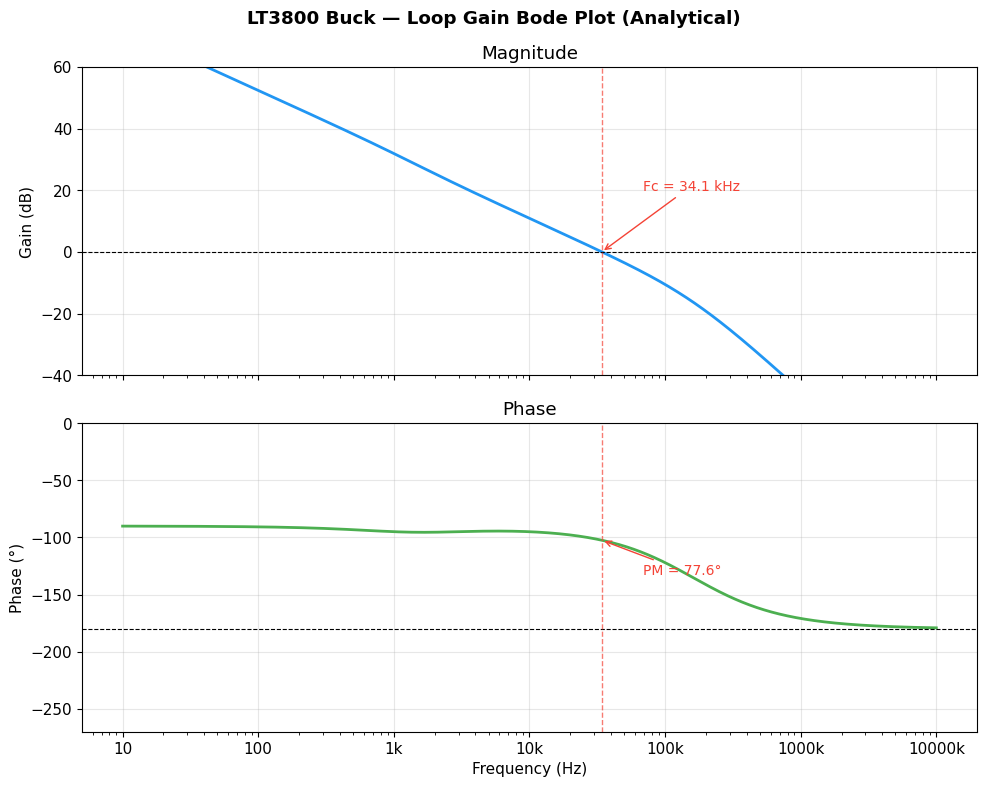

Saved: bode_plot.png


In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
fig.suptitle('LT3800 Buck — Loop Gain Bode Plot (Analytical)', fontweight='bold')

# ── Magnitude ─────────────────────────────────────────────────────
ax1.semilogx(f, T_dB, color='#2196F3')
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
if len(idx_cross) > 0:
    ax1.axvline(fc, color='#F44336', linewidth=1, linestyle='--', alpha=0.7)
    ax1.annotate(f'Fc = {fc/1e3:.1f} kHz',
                 xy=(fc, 0), xytext=(fc*2, 20),
                 arrowprops=dict(arrowstyle='->', color='#F44336'),
                 color='#F44336', fontsize=10)
ax1.set_ylabel('Gain (dB)')
ax1.set_ylim(-40, 60)
ax1.set_title('Magnitude')

# ── Phase ─────────────────────────────────────────────────────────
ax2.semilogx(f, T_ph, color='#4CAF50')
ax2.axhline(-180, color='black', linewidth=0.8, linestyle='--')
if len(idx_cross) > 0:
    ax2.axvline(fc, color='#F44336', linewidth=1, linestyle='--', alpha=0.7)
    ax2.annotate(f'PM = {pm:.1f}°',
                 xy=(fc, T_ph[idx_cross[-1]]),
                 xytext=(fc*2, T_ph[idx_cross[-1]]-30),
                 arrowprops=dict(arrowstyle='->', color='#F44336'),
                 color='#F44336', fontsize=10)
ax2.set_ylabel('Phase (°)')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylim(-270, 0)
ax2.set_title('Phase')
ax2.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k' if x >= 1000 else f'{x:.0f}'))

plt.tight_layout()
plt.savefig('bode_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: bode_plot.png")

## 4. Design Verdicts Summary

In [ ]:
dIL = (Vin - Vout) * D / (Fsw * L)
dVout_ripple = dIL / (8 * Fsw * Cout_eff)

print("=" * 55)
print(" LT3800 Buck Converter — Design Verdict Summary")
print("=" * 55)
print(f" Spec: {Vin}V → {Vout}V / {Iout_max}A @ {Fsw/1e3:.0f}kHz")
print("-" * 55)
print(f" Duty cycle              : {D:.3f} ({D*100:.1f}%)")
print(f" Inductor current ripple : {dIL*1e3:.1f} mA pk-pk")
print(f" Output voltage ripple   : {dVout_ripple*1e3:.1f} mV pk-pk (analytical)")
print(f"                           4.2 mV pk-pk (LTspice sim)")
print(f" Efficiency @ 2A         : {eta_pts[-1]:.1f}%")
print(f" Efficiency @ 500mA      : {eta_pts[1]:.1f}%")
if len(idx_cross) > 0:
    print(f" Crossover frequency     : {fc/1e3:.1f} kHz")
    print(f" Phase margin            : {pm:.1f}°")
    verdict = "STABLE" if pm > 45 else "MARGINAL" if pm > 30 else "UNSTABLE"
    print(f" Stability verdict       : {verdict}")
print("-" * 55)
print(" Key design decisions:")
print("  • Cout rated 10V on 3.3V rail — DC bias derating")
print(f"    mitigated: {Cout_eff*1e6:.0f}µF effective vs {Cout*1e6:.0f}µF nominal")
print("  • CSD17556Q5B: Rds(on)=6mΩ — conduction losses")
print("    minor vs inductor DCR at 200kHz")
print("  • Dominant loss: inductor DCR (43mΩ Bourns SRR1260)")
print("    ~60% of total losses at full load")
print("=" * 55)

 LT3800 Buck Converter — Design Verdict Summary
 Spec: 12.0V → 3.3V / 2.0A @ 200kHz
-------------------------------------------------------
 Duty cycle              : 0.275 (27.5%)
 Inductor current ripple : 543.8 mA pk-pk
 Output voltage ripple   : 4.7 mV pk-pk (analytical)
                           4.2 mV pk-pk (LTspice sim)
 Efficiency @ 2A         : 95.8%
 Efficiency @ 500mA      : 98.7%
 Crossover frequency     : 34.1 kHz
 Phase margin            : 77.6°
 Stability verdict       : STABLE
-------------------------------------------------------
 Key design decisions:
  • Cout rated 10V on 3.3V rail — DC bias derating
    mitigated: 72µF effective vs 100µF nominal
  • CSD17556Q5B: Rds(on)=6mΩ — conduction losses
    minor vs inductor DCR at 200kHz
  • Dominant loss: inductor DCR (43mΩ Bourns SRR1260)
    ~60% of total losses at full load


---
## Licence
This notebook is licensed under **CC BY-NC 4.0**.  
You are free to study and share it with attribution.  
Commercial reuse requires explicit permission.

---
*This is a sample deliverable. For a custom analysis of your power supply design,  
[hire me on Fiverr](#) — link to be added at launch.*